# Imports

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from scipy import stats


# Data 

In [2]:

df = pd.read_csv('gridwatch.csv')
df.columns = df.columns.str.strip()

# Parse and set correctly
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df = df.sort_index()

# Resample to daily 
df_daily = df.resample('D').mean() 

# Flag invasion date
invasion_date = '2022-02-24'
df_daily['post_invasion'] = (df_daily.index >= invasion_date).astype(int)

sources = ['coal', 'nuclear', 'ccgt', 'wind', 'solar', 'biomass', 'hydro']

for source in sources: 
    df_daily[f'{source}_pct'] = (df_daily[source] / df_daily['demand'] * 100)



# Exploratory Data Analysis

In [3]:
sources_pct = ['ccgt_pct', 'coal_pct', 'wind_pct', 'nuclear_pct', 'biomass_pct', 'solar_pct']

pre = df_daily[df_daily['post_invasion'] == 0][sources_pct]
post = df_daily[df_daily['post_invasion'] == 1][sources_pct]

means_table = pd.DataFrame({
    'Pre-invasion mean %': pre.mean().round(2),
    'Post-invasion mean %': post.mean().round(2),
    'Change (pp)': (post.mean() - pre.mean()).round(2)
})

print(means_table)


print("Source         | t-statistic | p-value | Significant?")
print("-" * 55)

for col in sources_pct:
    pre_clean = pre[col].dropna()
    post_clean = post[col].dropna()
    t, p = stats.ttest_ind(pre_clean, post_clean)
    sig = "Yes ***" if p < 0.05 else "No"
    print(f"{col:<15} | {t:>11.3f} | {p:.4f}  | {sig}")
    

df_its = df_daily[['ccgt_pct', 'post_invasion']].dropna().copy()
df_its['time'] = np.arange(len(df_its))

invasion_idx = df_its.index.get_loc(df_its.index[df_its.index >= '2022-02-24'][0])
df_its['time_since_invasion'] = np.where(
    df_its['post_invasion'] == 1,
    np.arange(len(df_its)) - invasion_idx,
    0
)

# Build X matrix manually
X = np.column_stack([
    np.ones(len(df_its)),
    df_its['time'],
    df_its['post_invasion'],
    df_its['time_since_invasion']
])
y = df_its['ccgt_pct'].values

# Run OLS using numpy
coeffs, residuals, rank, sv = np.linalg.lstsq(X, y, rcond=None)

# Calculate p-values manually
y_pred = X @ coeffs
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot
n, p = X.shape
se = np.sqrt(np.diag(ss_res / (n - p) * np.linalg.inv(X.T @ X)))
t_stats = coeffs / se
p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))

labels = ['const', 'time', 'post_invasion', 'time_since_invasion']
print(f"R-squared: {r_squared:.4f}\n")
print(f"{'Variable':<25} {'Coeff':>10} {'t-stat':>10} {'p-value':>10}")
print("-" * 58)
for label, coef, t, p in zip(labels, coeffs, t_stats, p_values):
    print(f"{label:<25} {coef:>10.4f} {t:>10.3f} {p:>10.4f}")

             Pre-invasion mean %  Post-invasion mean %  Change (pp)
ccgt_pct                   38.91                 33.48        -5.43
coal_pct                    1.71                  0.73        -0.98
wind_pct                   21.01                 25.94         4.93
nuclear_pct                17.91                 15.71        -2.21
biomass_pct                 7.25                  6.53        -0.72
solar_pct                   4.40                  5.76         1.37
Source         | t-statistic | p-value | Significant?
-------------------------------------------------------
ccgt_pct        |       9.005 | 0.0000  | Yes ***
coal_pct        |      15.185 | 0.0000  | Yes ***
wind_pct        |      -8.655 | 0.0000  | Yes ***
nuclear_pct     |      13.962 | 0.0000  | Yes ***
biomass_pct     |       7.012 | 0.0000  | Yes ***
solar_pct       |      -7.705 | 0.0000  | Yes ***
R-squared: 0.1441

Variable                       Coeff     t-stat    p-value
------------------------------------

# Data Communication and Analysis

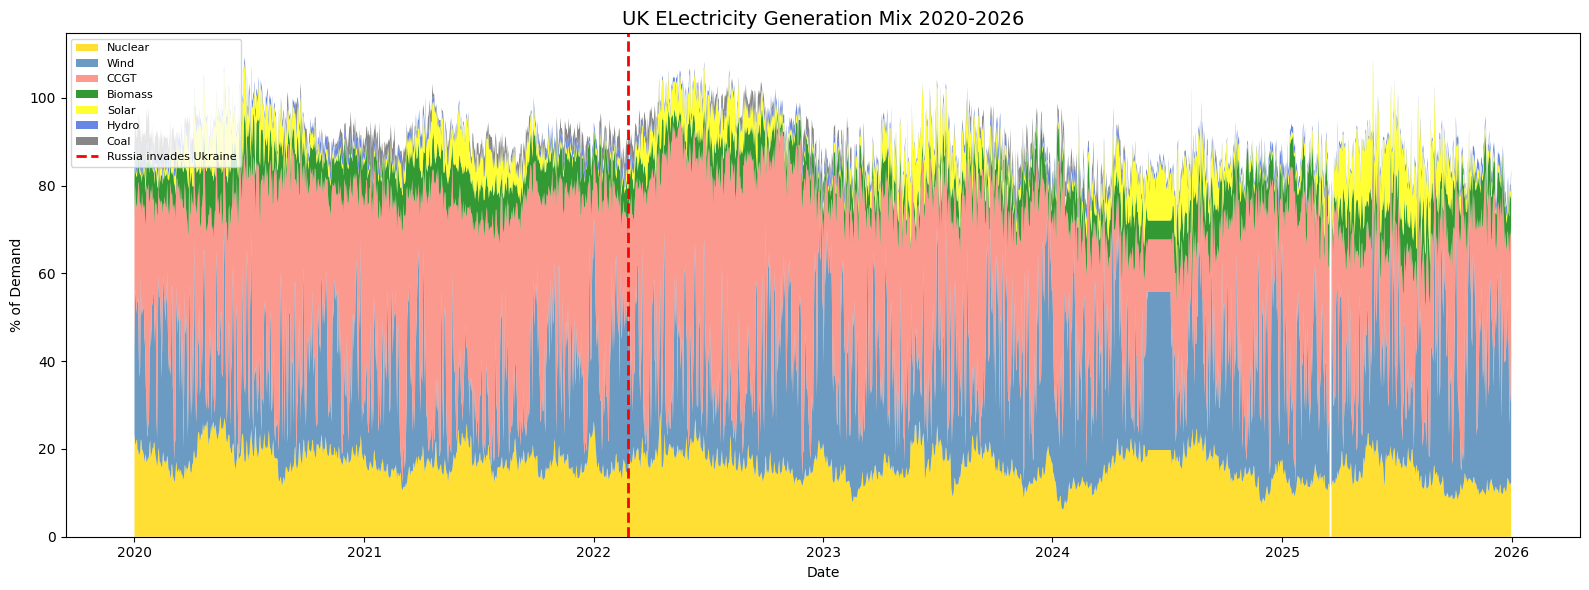

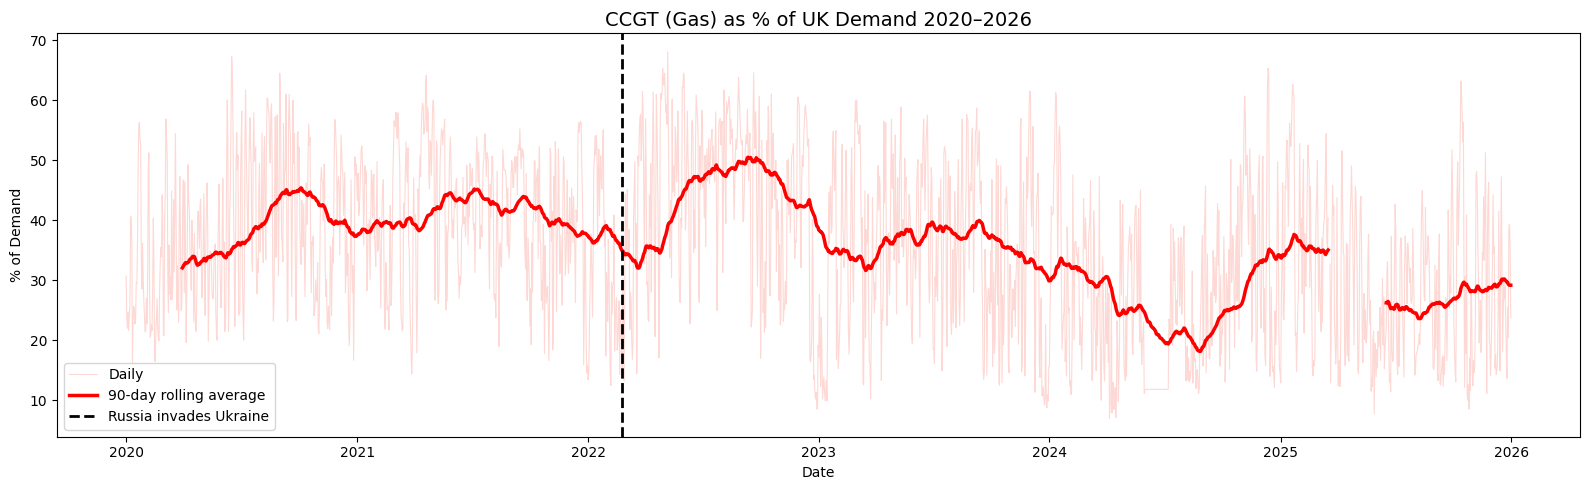

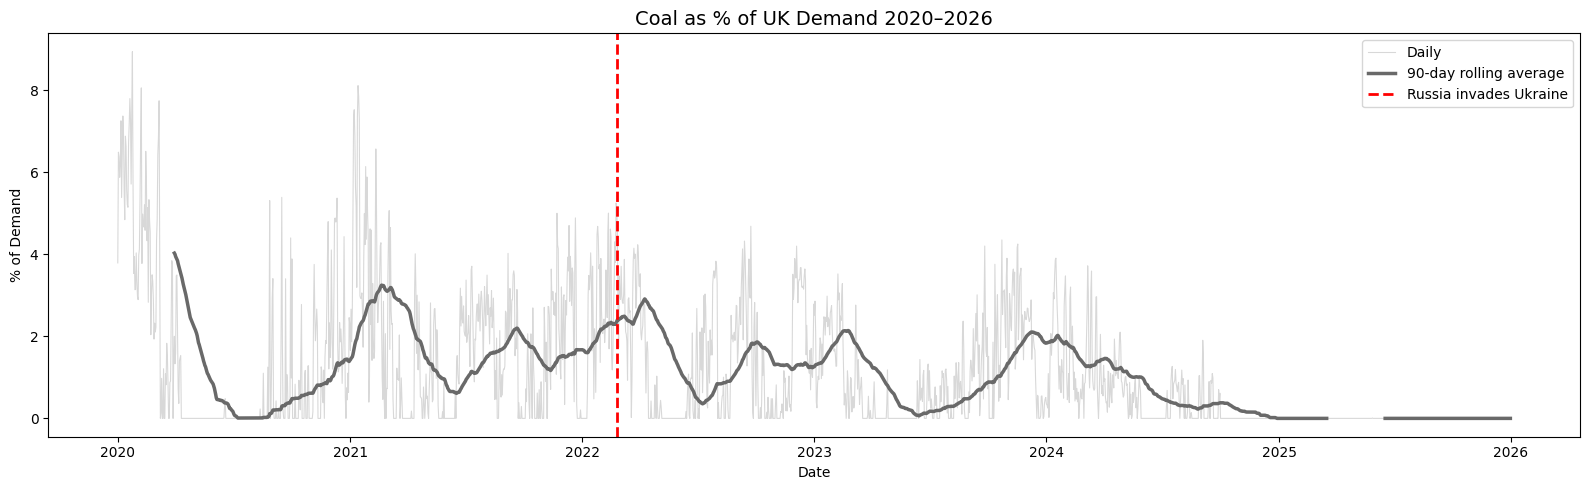

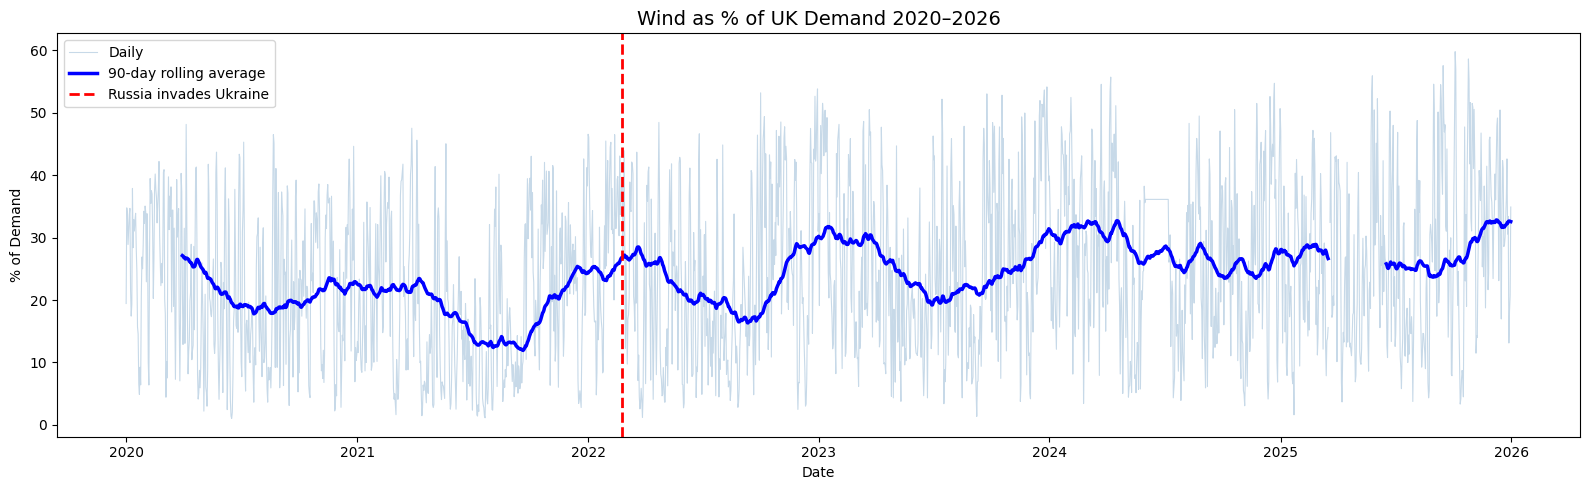

In [4]:
sources_pct = ['nuclear_pct', 'wind_pct', 'ccgt_pct', 'biomass_pct', 'solar_pct', 'hydro_pct', 'coal_pct']

colors = ['gold', 'steelblue', 'salmon', 'green', 'yellow', 'royalblue', 'dimgray']

fig, ax = plt.subplots(figsize=(16, 6))

ax.stackplot(df_daily.index, [df_daily[s] for s in sources_pct], labels = ['Nuclear', 'Wind', 'CCGT', 'Biomass', 'Solar', 'Hydro', 'Coal'], colors =colors, alpha=0.8)

ax.axvline(pd.Timestamp('2022-02-24'), color='red', linewidth=2, linestyle='--', label='Russia invades Ukraine') 

ax.set_title('UK ELectricity Generation Mix 2020-2026', fontsize=14)
ax.set_ylabel('% of Demand')
ax.set_xlabel('Date')
ax.legend(loc = 'upper left', fontsize = 8)
plt.tight_layout() 
plt.show() 


fig, ax = plt.subplots(figsize=(16, 5))

# Raw daily values (faint)
ax.plot(df_daily.index, df_daily['ccgt_pct'], 
        color='salmon', alpha=0.3, linewidth=0.8, label='Daily')

# 90-day rolling average (the important line)
ax.plot(df_daily.index, df_daily['ccgt_pct'].rolling(90).mean(), 
        color='red', linewidth=2.5, label='90-day rolling average')

# Invasion marker
ax.axvline(pd.Timestamp('2022-02-24'), color='black', linewidth=2, 
           linestyle='--', label='Russia invades Ukraine')

ax.set_title('CCGT (Gas) as % of UK Demand 2020–2026', fontsize=14)
ax.set_ylabel('% of Demand')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))

# Raw daily values (faint)
ax.plot(df_daily.index, df_daily['coal_pct'], 
        color='gray', alpha=0.3, linewidth=0.8, label='Daily')

# 90-day rolling average
ax.plot(df_daily.index, df_daily['coal_pct'].rolling(90).mean(), 
        color='dimgray', linewidth=2.5, label='90-day rolling average')

# Invasion marker
ax.axvline(pd.Timestamp('2022-02-24'), color='red', linewidth=2, 
           linestyle='--', label='Russia invades Ukraine')

ax.set_title('Coal as % of UK Demand 2020–2026', fontsize=14)
ax.set_ylabel('% of Demand')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(16, 5))

# Raw daily values (faint)
ax.plot(df_daily.index, df_daily['wind_pct'], 
        color='steelblue', alpha=0.3, linewidth=0.8, label='Daily')

# 90-day rolling average
ax.plot(df_daily.index, df_daily['wind_pct'].rolling(90).mean(), 
        color='blue', linewidth=2.5, label='90-day rolling average')

# Invasion marker
ax.axvline(pd.Timestamp('2022-02-24'), color='red', linewidth=2, 
           linestyle='--', label='Russia invades Ukraine')

ax.set_title('Wind as % of UK Demand 2020–2026', fontsize=14)
ax.set_ylabel('% of Demand')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()


    